<div style="background-color:#E3F2FD; color:#0D47A1; padding:15px; border-radius:10px;">

# ❤️ Heart Disease Prediction

Predicting the likelihood of heart disease using patient health and clinical information.

</div>

<br>

<div style="background-color:#F5F5F5; color:#212121; padding:15px; border-radius:10px;">

## 📌 Problem Statement

Heart disease is one of the leading causes of death worldwide. This project aims to build a machine learning model that predicts the presence of heart disease using patient medical data.

</div>

<br>

<div style="background-color:#E8F5E9; color:#1B5E20; padding:15px; border-radius:10px;">

## 🎯 Objectives

* Understand and explore the dataset.
* Perform data cleaning and preprocessing.
* Build and evaluate machine learning models.
* Identify key factors related to heart disease.

</div>

<br>

<div style="background-color:#FFF8E1; color:#E65100; padding:15px; border-radius:10px;">

## 💡 Please Suggest Improvements

Any feedback on analysis, visualizations, feature engineering, or model performance is highly appreciated.

</div>

<br>

<div style="background-color:#FCE4EC; color:#880E4F; padding:15px; border-radius:10px;">

## 📝 Note

This is my first Kaggle notebook and a learning project. Any constructive feedback or suggestions will help me improve my data science skills.

Thank you for visiting! 🚀

</div>


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zhaoyingzhu/heartcsv/Heart.csv


Dataset link :- https://www.kaggle.com/datasets/zhaoyingzhu/heartcsv

# 1. Data Understanding

In [2]:
data = pd.read_csv("/kaggle/input/datasets/zhaoyingzhu/heartcsv/Heart.csv")
df = pd.DataFrame(data)
df.head()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [3]:
df.shape

(303, 15)

In [4]:
print("Total Duplicates : ",df.duplicated().sum())

Total Duplicates :  0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   Age         303 non-null    int64  
 2   Sex         303 non-null    int64  
 3   ChestPain   303 non-null    object 
 4   RestBP      303 non-null    int64  
 5   Chol        303 non-null    int64  
 6   Fbs         303 non-null    int64  
 7   RestECG     303 non-null    int64  
 8   MaxHR       303 non-null    int64  
 9   ExAng       303 non-null    int64  
 10  Oldpeak     303 non-null    float64
 11  Slope       303 non-null    int64  
 12  Ca          299 non-null    float64
 13  Thal        301 non-null    object 
 14  AHD         303 non-null    object 
dtypes: float64(2), int64(10), object(3)
memory usage: 35.6+ KB


In [6]:
spelling_check = ["ChestPain","Thal","AHD"]
for col in spelling_check:
    print(f"Column Name {col} : ")
    print(df[col].unique())
    print()

Column Name ChestPain : 
['typical' 'asymptomatic' 'nonanginal' 'nontypical']

Column Name Thal : 
['fixed' 'normal' 'reversable' nan]

Column Name AHD : 
['No' 'Yes']



The above shows that there are no spelling mismatches, such as a word being in lowercase (say, 'typical') in one instance and uppercase in another.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,303.0,152.000000,87.612784,1.0,76.5,152.0,227.5,303.0
Age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
Sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
RestBP,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
Chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
Fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
RestECG,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
MaxHR,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
ExAng,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
Oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


# 2. Data Cleaning

## 2.1 Removing Redundant Column

In [8]:
df = df.drop(columns='Unnamed: 0')
df.head(2)

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes


## 2.2 Filling Missing Values

In [9]:
# Filter and show only columns with at least one null value
df.isna().sum()[df.isna().sum() > 0]

Ca      4
Thal    2
dtype: int64

In [10]:
# 1. Filling Numerical 
df["Ca"] = df["Ca"].fillna(df["Ca"].median()) 

# 2. Filling Categorical
df['Thal'] = df['Thal'].fillna(df['Thal'].mode()[0])

## 2.3 Transforming Column Values

### 2.3.1 Categorial to Numerical

In [11]:
# Replace the text AND explicitly set the type to integer
df['AHD'] = df['AHD'].replace({'Yes': 1, 'No': 0}).astype(int)
df["AHD"].head()

/tmp/ipykernel_1499/3084321789.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['AHD'] = df['AHD'].replace({'Yes': 1, 'No': 0}).astype(int)


0    0
1    1
2    1
3    0
4    0
Name: AHD, dtype: int64

### 2.3.2 Numerical to Categorial

In [12]:
# 1. Transform Resting Electrocardiographic Results (RestECG)
restecg_map = {
    0: "Normal",
    1: "ST-T wave abnormality",
    2: "Left ventricular hypertrophy"
}
df['RestECG'] = df['RestECG'].map(restecg_map)

# 2. Transform Slope of the peak exercise ST segment (Slope)
slope_map = {
    1: "Upsloping",
    2: "Flat",
    3: "Downsloping"
}
df['Slope'] = df['Slope'].map(slope_map)

# Verify the transformations worked perfectly
print(df[['RestECG', 'Slope']].head())

                        RestECG        Slope
0  Left ventricular hypertrophy  Downsloping
1  Left ventricular hypertrophy         Flat
2  Left ventricular hypertrophy         Flat
3                        Normal  Downsloping
4  Left ventricular hypertrophy    Upsloping


## 2.4 Renaming Columns

In [13]:
# Dictionary mapping old column names to new column names
rename_dict = {
    "Sex": "is_male",  
    "ChestPain": "chest_pain",
    "MaxHR": "max_heart_rate",
    "Ca": "major_vessels",
    "Thal": "thalassemia",
    "AHD": "heart_disease"
}

# Rename the columns in place
df = df.rename(columns=rename_dict)

# 3. EDA

## 📖 Feature Description

| Feature          | Description                                                                                                         |
| ---------------- | ------------------------------------------------------------------------------------------------------------------- |
| `chest_pain`     | Type of chest pain experienced by the patient (Typical Angina, Atypical Angina, Non-anginal Pain, or Asymptomatic). |
| `RestBP`         | Resting blood pressure (mm Hg) measured when the patient is at rest.                                                |
| `Chol`           | Serum cholesterol level in mg/dL.                                                                                   |
| `Fbs`            | Indicates whether fasting blood sugar is greater than 120 mg/dL (0 = No, 1 = Yes).                                  |
| `RestECG`        | Resting electrocardiographic results.                                                                               |
| `max_heart_rate` | Maximum heart rate achieved during exercise testing.                                                                |
| `ExAng`          | Exercise-induced angina (0 = No, 1 = Yes).                                                                          |
| `Oldpeak`        | ST depression induced by exercise relative to rest.                                                                 |
| `Slope`          | Slope of the peak exercise ST segment.                                                                              |
| `major_vessels`  | Number of major blood vessels colored by fluoroscopy.                                                               |
| `thalassemia`    | Thalassemia test result indicating blood disorder status.                                                           |
| `is_male`        | Patient's gender (0 = Female, 1 = Male).                                                                            |
| `heart_disease`  | Target variable indicating the presence or absence of heart disease.                                                |


In [14]:
# Column based on dtyppe present
num_cols = ['Age', 'RestBP', 'Chol', 'max_heart_rate', 'Oldpeak']
cat_cols = ['is_male', 'chest_pain', 'Fbs', 'RestECG', 'ExAng', 'Slope', 'major_vessels', 'thalassemia', 'heart_disease']

## 3.1 Univariate Analysis

### 3.1.1 Numerical columns(Histograms & Boxplots)
##### This will show you the distribution, skewness, and potential outliers for your continuous numbers.

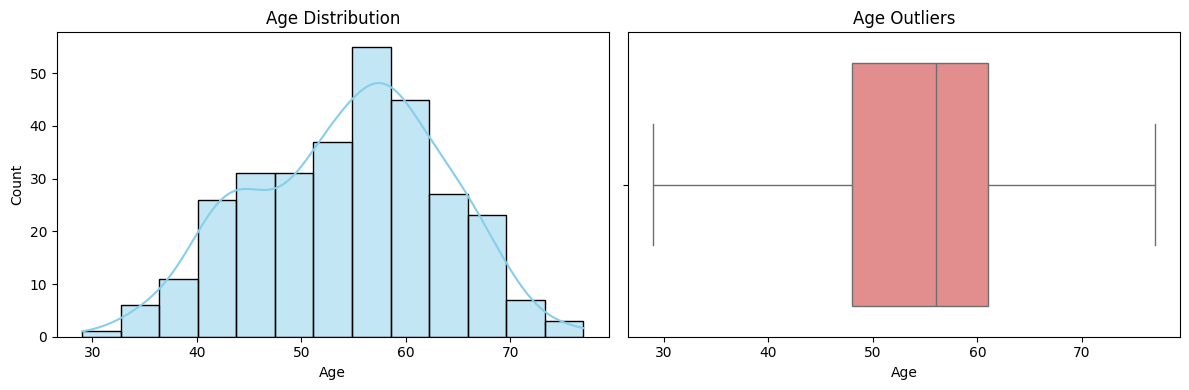

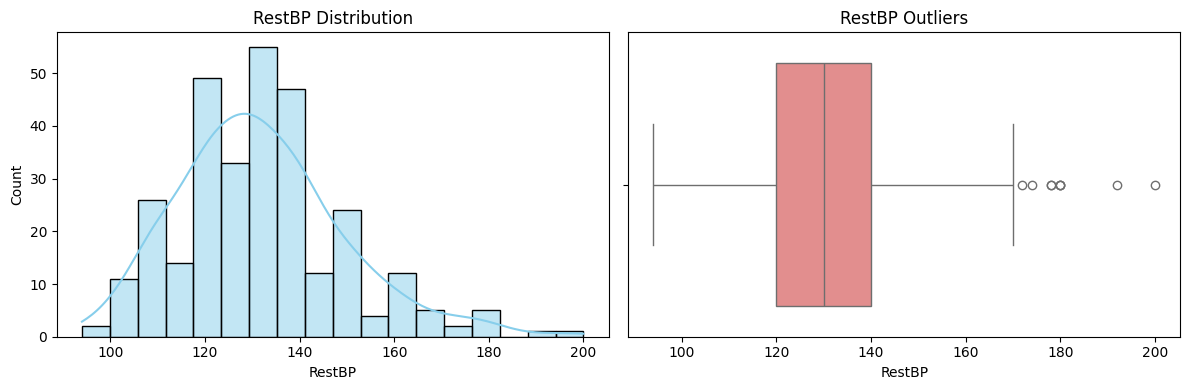

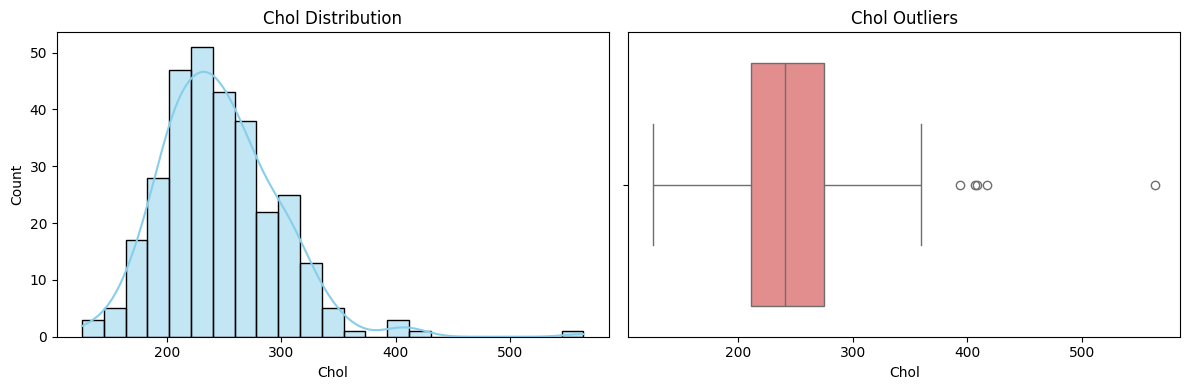

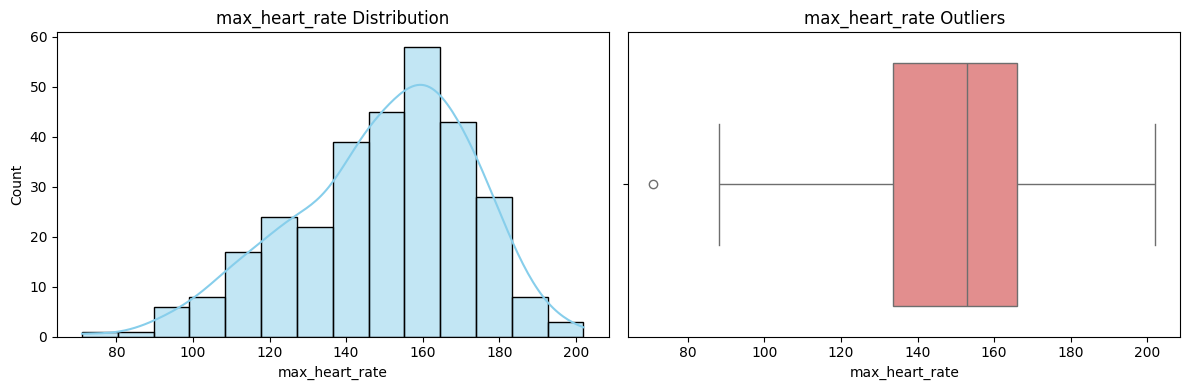

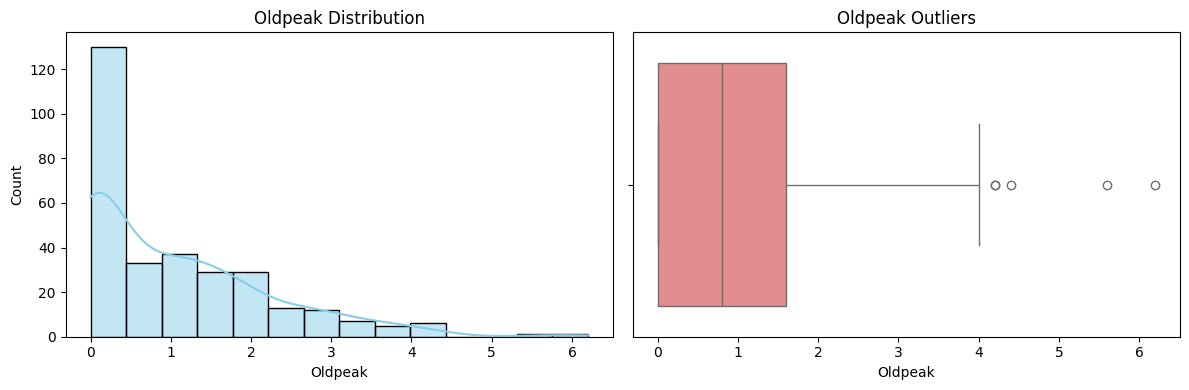

In [15]:
# Set the style
# sns.set_theme(style="whitegrid")

# Plot Histograms and Boxplots side-by-side for each numerical column
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE curve
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} Distribution')
    
    # Boxplot for outliers
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} Outliers')
    
    plt.tight_layout()
    plt.show()

### 3.1.2 Categorical Columns (Count plots)

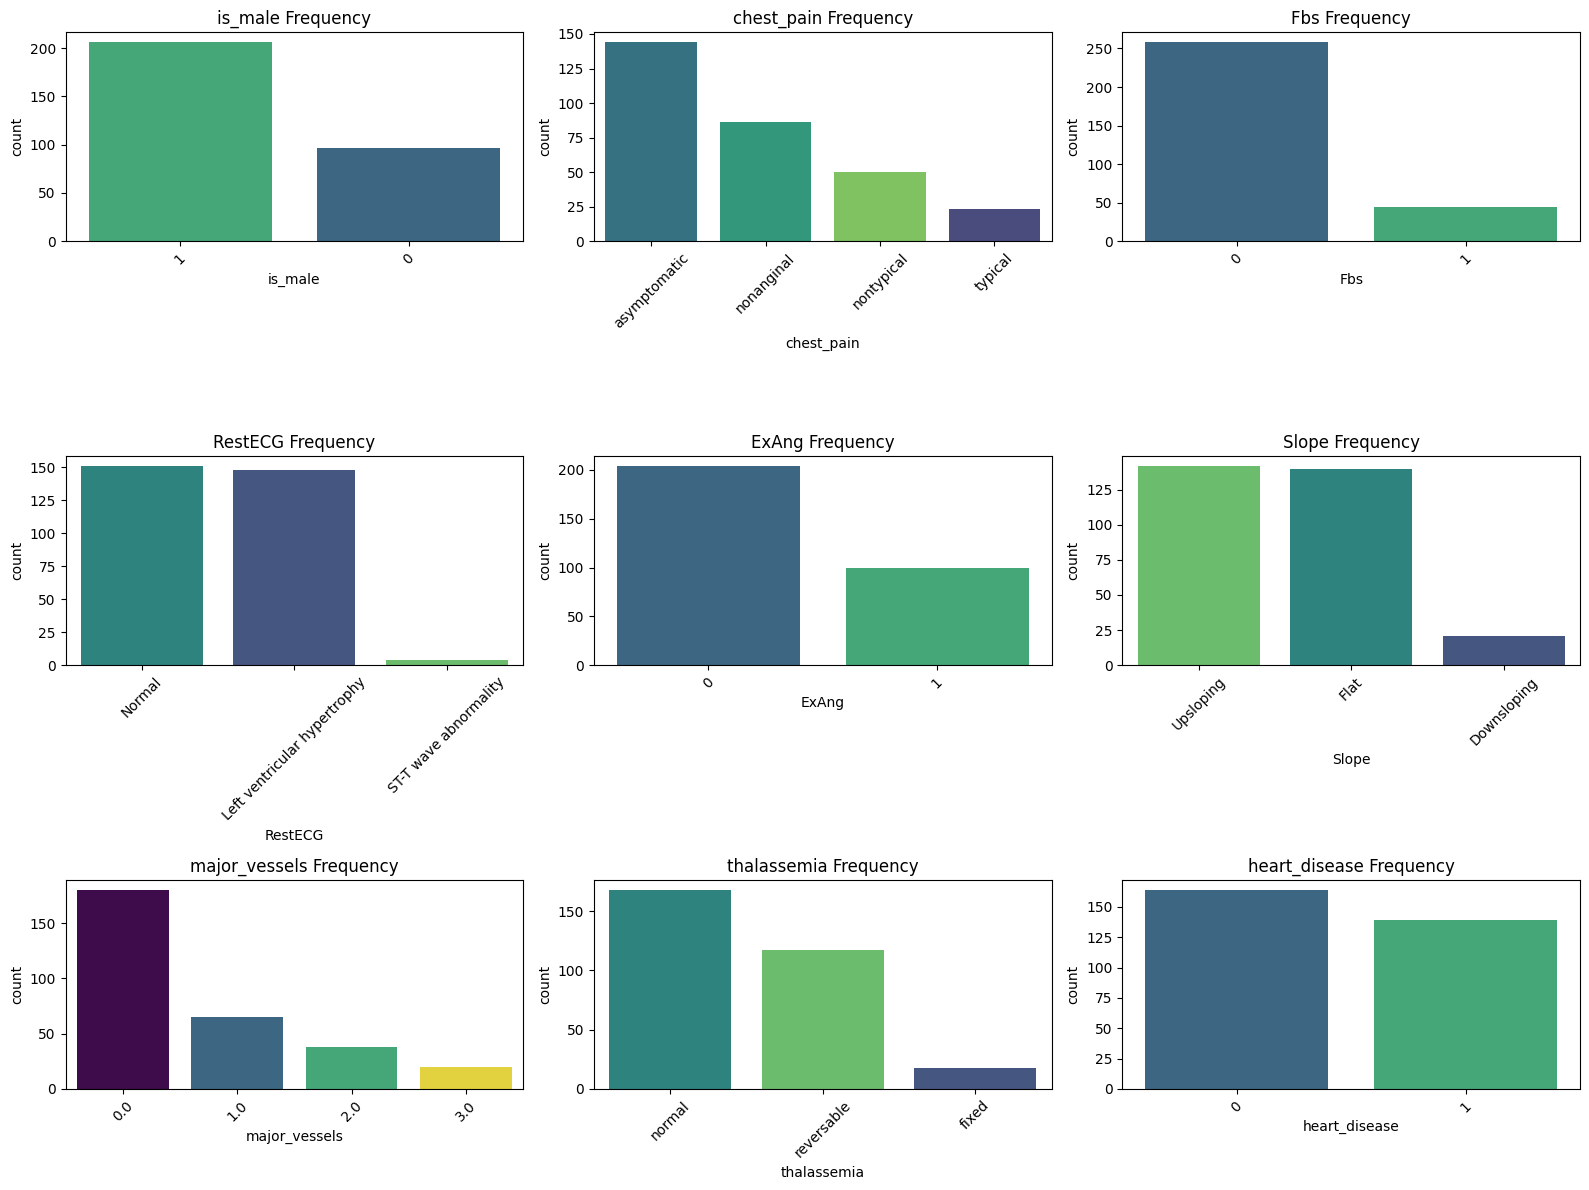

In [16]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)
    
    sns.countplot(
        data=df, 
        x=col, 
        hue=col, 
        order=df[col].value_counts().index, 
        palette='viridis', 
        legend=False
    )
    
    plt.title(f'{col} Frequency')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.2 Bivariate Analysis

### 3.2.1 Numerical vs. Numerical

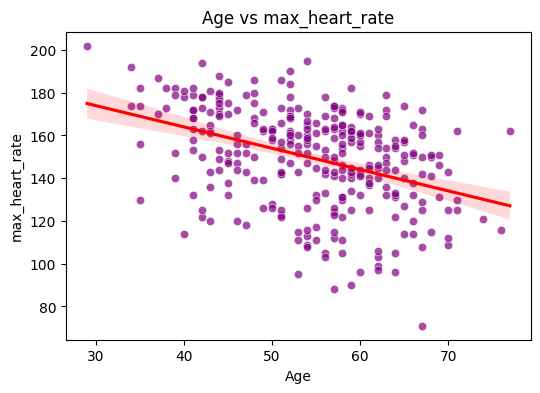

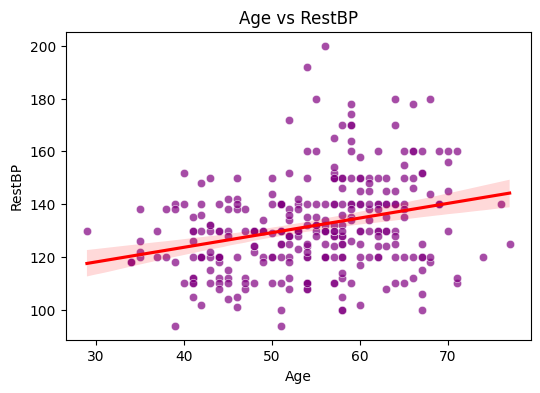

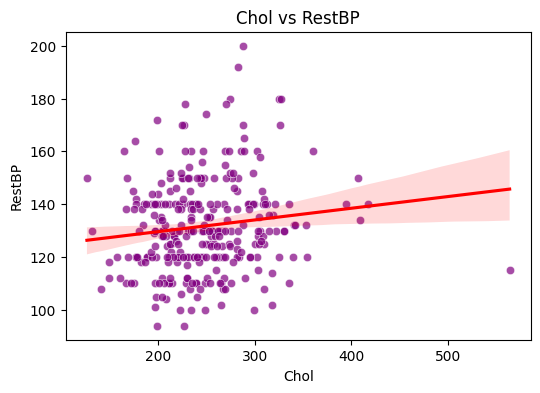

In [17]:
# Updated to use your new column name 'max_heart_rate'
num_pairs = [('Age', 'max_heart_rate'), ('Age', 'RestBP'), ('Chol', 'RestBP')]

for x_col, y_col in num_pairs:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=x_col, y=y_col, alpha=0.7, color='purple')
    sns.regplot(data=df, x=x_col, y=y_col, scatter=False, color='red') 
    plt.title(f'{x_col} vs {y_col}')
    plt.show()

### 3.2.2 Categorical vs. Categorical

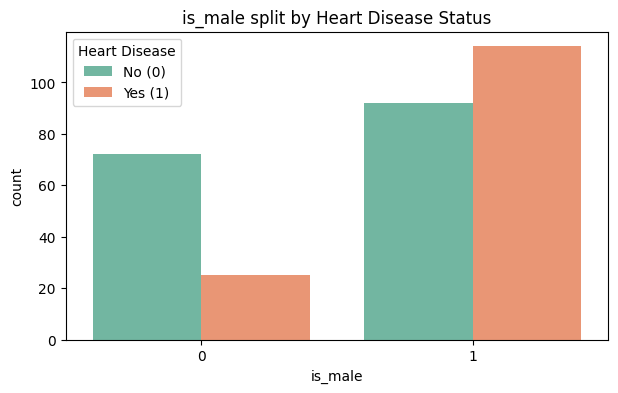

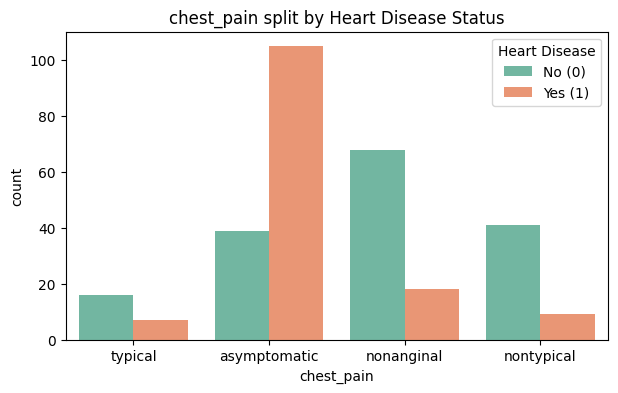

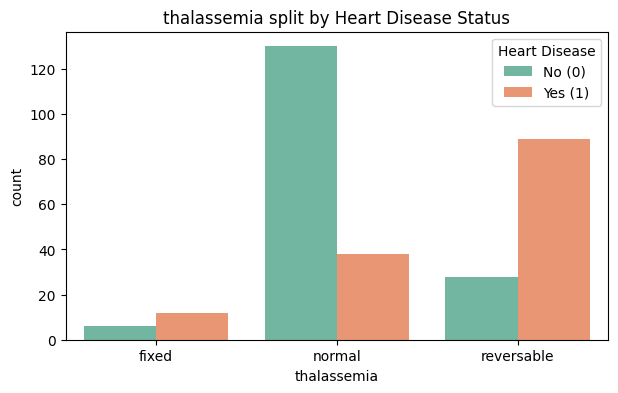

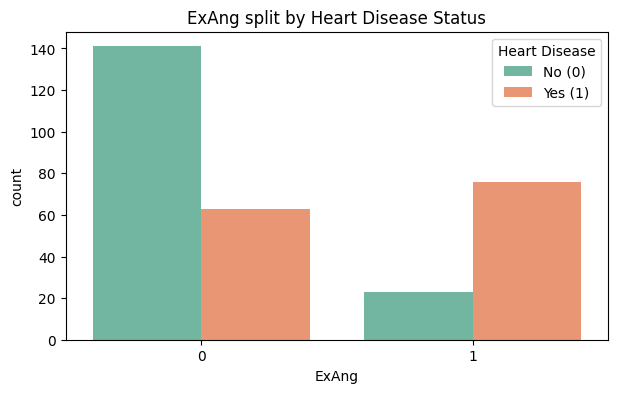

In [18]:
# Looking at demographics and symptoms against your target 'heart_disease'
features_to_check = ['is_male', 'chest_pain', 'thalassemia', 'ExAng']

for col in features_to_check:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, hue='heart_disease', palette='Set2')
    plt.title(f'{col} split by Heart Disease Status')
    plt.legend(title='Heart Disease', labels=['No (0)', 'Yes (1)'])
    plt.show()

### 3.2.3 Numerical vs. Categorical

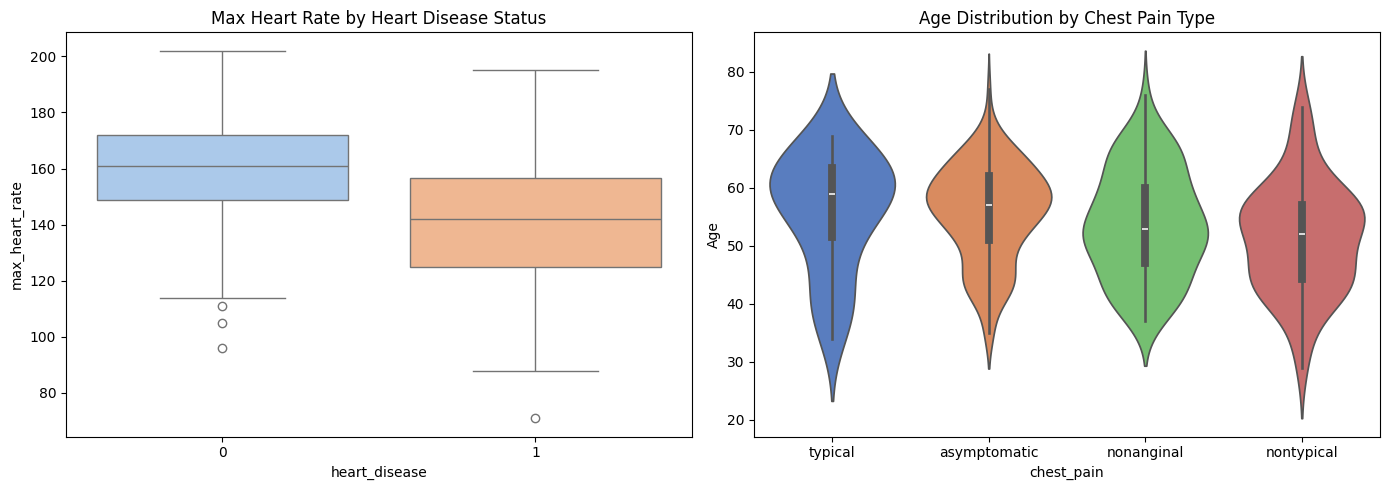

In [19]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(
    data=df, 
    x='heart_disease', 
    y='max_heart_rate', 
    hue='heart_disease', 
    palette='pastel', 
    legend=False
)
plt.title('Max Heart Rate by Heart Disease Status')

# Example 2: Age by Chest Pain Type
plt.subplot(1, 2, 2)
# FIX: Added hue='chest_pain' and legend=False
sns.violinplot(
    data=df, 
    x='chest_pain', 
    y='Age', 
    hue='chest_pain', 
    palette='muted', 
    legend=False
)
plt.title('Age Distribution by Chest Pain Type')

plt.tight_layout()
plt.show()

## 3.3 Multivariate Analysis

### 3.3.1 Correlation Matrix Heatmap

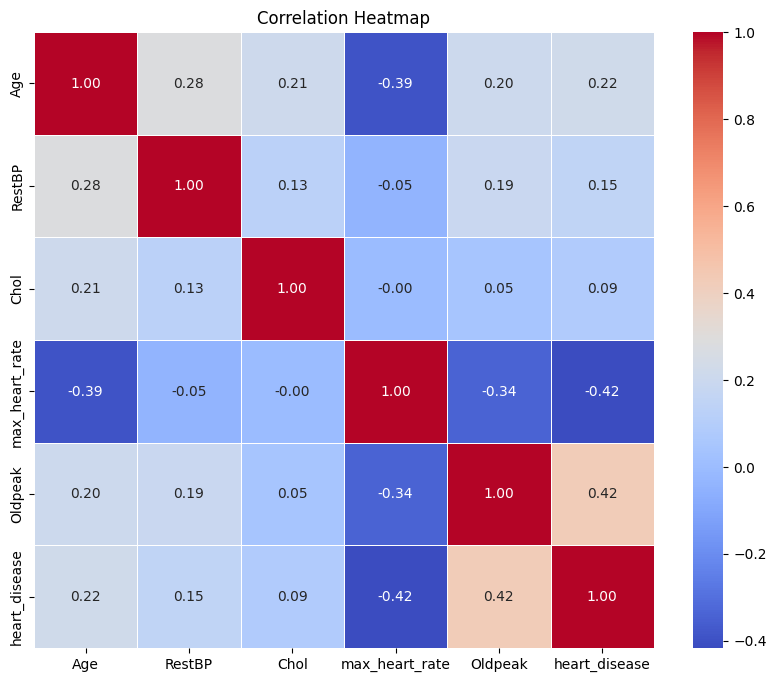

In [20]:
plt.figure(figsize=(10, 8))

# Calculates linear correlations using your updated names
corr_matrix = df[num_cols + ['heart_disease']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# 4. Data Preprocessing

In [21]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             303 non-null    int64  
 1   is_male         303 non-null    int64  
 2   chest_pain      303 non-null    object 
 3   RestBP          303 non-null    int64  
 4   Chol            303 non-null    int64  
 5   Fbs             303 non-null    int64  
 6   RestECG         303 non-null    object 
 7   max_heart_rate  303 non-null    int64  
 8   ExAng           303 non-null    int64  
 9   Oldpeak         303 non-null    float64
 10  Slope           303 non-null    object 
 11  major_vessels   303 non-null    float64
 12  thalassemia     303 non-null    object 
 13  heart_disease   303 non-null    int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 33.3+ KB


In [23]:
df.columns

Index(['Age', 'is_male', 'chest_pain', 'RestBP', 'Chol', 'Fbs', 'RestECG',
       'max_heart_rate', 'ExAng', 'Oldpeak', 'Slope', 'major_vessels',
       'thalassemia', 'heart_disease'],
      dtype='object')

In [24]:
# Implementing OneHotEncoding -> Converting Categorical to numeric
df = pd.get_dummies(data=df,columns=['chest_pain','thalassemia','RestECG','Slope'],drop_first = True,dtype=int)
df.head()

,Age,is_male,RestBP,Chol,Fbs,max_heart_rate,ExAng,Oldpeak,major_vessels,heart_disease,chest_pain_nonanginal,chest_pain_nontypical,chest_pain_typical,thalassemia_normal,thalassemia_reversable,RestECG_Normal,RestECG_ST-T wave abnormality,Slope_Flat,Slope_Upsloping
0,63,1,145,233,1,150,0,2.3,0.0,0,0,0,1,0,0,0,0,0,0
1,67,1,160,286,0,108,1,1.5,3.0,1,0,0,0,1,0,0,0,1,0
2,67,1,120,229,0,129,1,2.6,2.0,1,0,0,0,0,1,0,0,1,0
3,37,1,130,250,0,187,0,3.5,0.0,0,1,0,0,1,0,1,0,0,0
4,41,0,130,204,0,172,0,1.4,0.0,0,0,1,0,1,0,0,0,0,1


In [25]:
# Splitting data so test data remained untouched
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

In [26]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
# Implement StandardScaler to eliminate scaling bias across numerical features.

all_numeric_cols  = X_train.select_dtypes(include='number').columns

cols_to_scale  = [c for c in all_numeric_cols  if df[c].nunique() > 2]  # keep only non-binary numeric columns and scale them

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform ONLY if using fit_transform so X_test uses it's own mean value
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [28]:
X_train_df = pd.DataFrame(X_train)
X_train_df.head()

,Age,is_male,RestBP,Chol,Fbs,max_heart_rate,ExAng,Oldpeak,major_vessels,chest_pain_nonanginal,chest_pain_nontypical,chest_pain_typical,thalassemia_normal,thalassemia_reversable,RestECG_Normal,RestECG_ST-T wave abnormality,Slope_Flat,Slope_Upsloping
132,-2.838504,1,-0.125982,-0.864142,0,2.314470,0,-0.873573,-0.715869,0,1,0,1,0,0,0,0,1
202,0.241352,1,0.974653,-2.483637,1,1.021242,0,-0.704854,0.401810,1,0,0,0,1,1,0,0,1
196,1.561291,1,1.524970,-0.241260,1,-0.851710,0,-0.789214,0.401810,0,0,1,1,0,0,0,1,0
75,1.121311,0,1.524970,2.374848,0,0.040172,0,-0.198698,-0.715869,1,0,0,1,0,0,0,0,1
176,-0.308622,1,-1.336680,-0.262023,1,-0.138205,0,-0.789214,2.637167,0,0,0,0,1,1,0,0,1


# 5. Model Selection & Hyperparameter Tuning

In [29]:
from sklearn.model_selection import KFold

In [30]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 6. Machine Learning

In [31]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier  
from xgboost import XGBClassifier                   
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [32]:
# Initialize the base models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),  # <-- Added
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')  # <-- Added
}

In [33]:
param_grids = {
    "Logistic Regression": {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs']
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance']
    },
    "SVC": {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    },
    "Decision Tree": {
        'max_depth': [None, 5, 10, 15, 20],
        'criterion': ['gini', 'entropy'],
        'min_samples_split': [2, 5, 10]
    },
    "Random Forest": {  
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'max_features': ['sqrt', 'log2']
    },
    "XGBoost": {  
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }
}

In [34]:
results = {}
best_models = {}

for name, model in models.items():

    print(f"\nRunning GridSearchCV for {name}...")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=kf,
        scoring='accuracy',   
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    results[name] = {
        "Best Params": grid.best_params_,
        "Best CV Score (R2)": grid.best_score_
    }

    best_models[name] = grid.best_estimator_  

    print(f"\n{name}")
    print("Best Params:", grid.best_params_)
    print("Best CV Score (R2):", grid.best_score_)


Running GridSearchCV for Logistic Regression...

Logistic Regression
Best Params: {'C': 0.1, 'solver': 'lbfgs'}
Best CV Score (R2): 0.8389455782312926

Running GridSearchCV for KNN...

KNN
Best Params: {'n_neighbors': 9, 'weights': 'distance'}
Best CV Score (R2): 0.7936224489795919

Running GridSearchCV for SVC...

SVC
Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score (R2): 0.8389455782312926

Running GridSearchCV for Decision Tree...

Decision Tree
Best Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}
Best CV Score (R2): 0.7187925170068027

Running GridSearchCV for Random Forest...

Random Forest
Best Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
Best CV Score (R2): 0.797704081632653

Running GridSearchCV for XGBoost...

XGBoost
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV Score (R2): 0.7976190476190476


In [35]:
# DataFram of results to make it more readable
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Best CV Score (R2)", ascending=False)

,Best Params,Best CV Score (R2)
Logistic Regression,"{'C': 0.1, 'solver': 'lbfgs'}",0.838946
SVC,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}",0.838946
Random Forest,"{'max_depth': 5, 'max_features': 'sqrt', 'min_...",0.797704
XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.797619
KNN,"{'n_neighbors': 9, 'weights': 'distance'}",0.793622
Decision Tree,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.718793


In [36]:
best_model_name = max(
    results,
    key=lambda x: results[x]["Best CV Score (R2)"]
)

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [37]:
best_model = best_models[best_model_name]

In [38]:
y_pred = best_model.predict(X_test)

In [39]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Test Accuracy: 0.8360655737704918
              precision    recall  f1-score   support

           0       0.79      0.90      0.84        29
           1       0.89      0.78      0.83        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



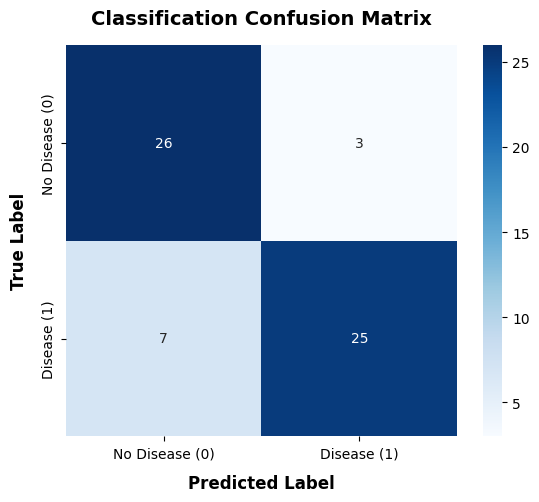

In [40]:
# 1. Compute the confusion matrix values
# (Assuming 0 = No Heart Disease, 1 = Heart Disease)
cm = confusion_matrix(y_test, y_pred)

# 2. Set up the plot dimensions
plt.figure(figsize=(6, 5))

# 3. Plot the heatmap
sns.heatmap(
    cm, 
    annot=True,          # Displays the actual numbers inside the squares
    fmt='d',             # Format as integers (prevents scientific notation)
    cmap='Blues',        # Blue color gradient palette
    square=True,         # Makes the cells perfectly square shaped
    xticklabels=['No Disease (0)', 'Disease (1)'], 
    yticklabels=['No Disease (0)', 'Disease (1)']
)

# 4. Add clear labels and formatting
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True Label', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Classification Confusion Matrix', fontsize=14, fontweight='bold', pad=15)

# 5. Render the plot cleanly
plt.tight_layout()
plt.show()

# 🩺 Model Evaluation & Key Insights

## 1. Model Performance Summary
Based on the 5-fold cross-validation grid search ($R^2$ scores) and test performance, here is how the models compare:

| Model Hierarchy | Optimal Parameters | Best CV Score ($R^2$) |
| :--- | :--- | :--- |
| **🥇 Logistic Regression** | `{'C': 0.1, 'solver': 'lbfgs'}` | **0.8389** |
| **🥈 Support Vector Classifier (SVC)** | `{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}` | **0.8389** |
| **🥉 Random Forest** | `{'max_depth': 5, 'max_features': 'sqrt'}` | 0.7977 |
| **4. XGBoost** | `{'learning_rate': 0.1, 'max_depth': 3}` | 0.7976 |
| **5. K-Nearest Neighbors (KNN)** | `{'n_neighbors': 9, 'weights': 'distance'}` | 0.7936 |
| **6. Decision Tree** | `{'criterion': 'entropy', 'max_depth': 5}` | 0.7188 |

---

## 🔍 2. Detailed Key Insights

### 📊 Model Performance Matrix
* **Logistic Regression** and **Support Vector Classifier (SVC)** achieved the highest cross-validation score (**0.839**), outperforming more complex models such as Random Forest and XGBoost.
* This suggests that the relationship between the features and the target variable is relatively linear and can be effectively captured by simpler models. Complex tree-based ensembles tended to overfit the underlying noise in this clinical dataset.

### 🏆 Best Selected Model
* **Logistic Regression** was selected as the final champion model with the following optimized parameters:
  * `C = 0.1` (Strong L2 regularization to control complexity)
  * `Solver = lbfgs`
* The model achieved a final **test accuracy of 83.61%**, demonstrating highly reliable generalization capabilities on completely unseen data.

### 📈 Classification Performance Breakdown
* **For patients without heart disease (Class 0):**
  * Precision: **0.79**
  * Recall: **0.90**
  * F1-Score: **0.84**
* **For patients with heart disease (Class 1):**
  * Precision: **0.89**
  * Recall: **0.78**
  * F1-Score: **0.83**

### 🎯 Confusion Matrix Analysis
Evaluating the 61 test patient samples reveals the exact alignment of model errors:
* **True Negatives (TN):** 26 (Healthy correctly identified)
* **False Positives (FP):** 3 (Healthy wrongly flagged as sick)
* **False Negatives (FN):** 7 (Sick missed by the model)
* **True Positives (TP):** 25 (Sick correctly identified)

**Key Observations:**
* The model successfully classified **51 out of 61 total patients**.
* Only **3 healthy patients** were incorrectly predicted as having heart disease, displaying high precision for clinical diagnostics.
* **7 heart disease cases** were missed. From a risk perspective, missing a sick patient (False Negative) is highly hazardous in medicine, indicating targeted room for improvement in sensitivity.
* Overall, the model displays a strong, well-rounded balance between precision and recall, establishing itself as a sound fit for heart disease prediction tasks.

---

## 💡 3. Overall Conclusion & Next Steps

* **Simpler Wins:** Simple, highly-regularized linear classifiers (Logistic Regression and Linear SVC) confidently outperformed deep tree-based ensemble frameworks on this tabular dataset.
* **Stable Deployment:** The final tuned Logistic Regression model delivers reliable, well-balanced predictions hovering near the **84%** mark across standard classification metrics.
* **Strategic Improvements:** Future work should focus aggressively on reducing the 7 false negatives. This can be pursued through domain-specific feature engineering, adjusting the probability classification threshold downwards (e.g., from `0.5` to `0.4`), or incorporating a larger, more balanced pool of clinical patient records.